In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [50]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    RAW_DATA_DIR = "/kaggle/input/competitions/kkbox-churn-prediction-challenge/"
    MODELS_DIR = "/kaggle/working/"
else:
    RAW_DATA_DIR = "../raw_data/"
    MODELS_DIR = "../models/"

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Environment: {'Kaggle' if ON_KAGGLE else 'Local'}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")
print(f"MODELS_DIR:   {MODELS_DIR}")

if os.path.exists(RAW_DATA_DIR):
    print(f"Files: {os.listdir(RAW_DATA_DIR)}")

Environment: Kaggle
RAW_DATA_DIR: /kaggle/input/competitions/kkbox-churn-prediction-challenge/
MODELS_DIR:   /kaggle/working/
Files: ['transactions_v2.csv.7z', 'WSDMChurnLabeller.scala', 'transactions.csv.7z', 'train.csv.7z', 'train_v2.csv.7z', 'user_logs.csv.7z', 'members_v3.csv.7z', 'sample_submission_zero.csv.7z', 'user_logs_v2.csv.7z', 'sample_submission_v2.csv.7z']


In [3]:
# --- Environment detection ---
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    SOURCE_DIR = "/kaggle/input/competitions/kkbox-churn-prediction-challenge/"
    EXTRACT_DIR = "/kaggle/working/raw_data/"
    MODELS_DIR = "/kaggle/working/"
else:
    # Local fallback: assumes you've already decompressed the .7z files
    # into ../raw_data/ next to your notebook
    SOURCE_DIR = "../raw_data/"
    EXTRACT_DIR = "../raw_data/"
    MODELS_DIR = "../models/"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"Environment: {'Kaggle' if ON_KAGGLE else 'Local'}")
print(f"SOURCE_DIR:  {SOURCE_DIR}")
print(f"EXTRACT_DIR: {EXTRACT_DIR}")

Environment: Kaggle
SOURCE_DIR:  /kaggle/input/competitions/kkbox-churn-prediction-challenge/
EXTRACT_DIR: /kaggle/working/raw_data/


In [5]:
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    SOURCE_DIR = "/kaggle/input/competitions/kkbox-churn-prediction-challenge/"
    EXTRACT_DIR = "/kaggle/working/raw_data/"
    MODELS_DIR = "/kaggle/working/"
else:
    SOURCE_DIR = "../raw_data/"
    EXTRACT_DIR = "../raw_data/"
    MODELS_DIR = "../models/"

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

files_to_extract = [
    "train.csv.7z",
    "members_v3.csv.7z",
    "transactions.csv.7z",
    #"user_logs.csv.7z",  # only later, very large
]

if ON_KAGGLE:
    for fname in files_to_extract:
        src = os.path.join(SOURCE_DIR, fname)
        expected_csv = os.path.join(EXTRACT_DIR, fname.replace(".7z", ""))

        if os.path.exists(expected_csv):
            print(f"Already extracted: {expected_csv}")
            continue

        print(f"Extracting {fname} ...")
        subprocess.run(
            ["7z", "x", src, f"-o{EXTRACT_DIR}", "-y"],
            check=True
        )

RAW_DATA_DIR = EXTRACT_DIR

print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("Files:", os.listdir(RAW_DATA_DIR))

Already extracted: /kaggle/working/raw_data/train.csv
Already extracted: /kaggle/working/raw_data/members_v3.csv
Already extracted: /kaggle/working/raw_data/transactions.csv
RAW_DATA_DIR: /kaggle/working/raw_data/
Files: ['transactions.csv', 'train.csv', 'members_v3.csv']


In [6]:
train = pd.read_csv(RAW_DATA_DIR + "train.csv")
members = pd.read_csv(RAW_DATA_DIR + "members_v3.csv")
transactions = pd.read_csv(RAW_DATA_DIR + "transactions.csv")

print(f"train:        {train.shape}")
print(f"members:      {members.shape}")
print(f"transactions: {transactions.shape}")

train:        (992931, 2)
members:      (6769473, 6)
transactions: (21547746, 9)


In [27]:
CUTOFF_DATE = pd.Timestamp("2017-02-01")

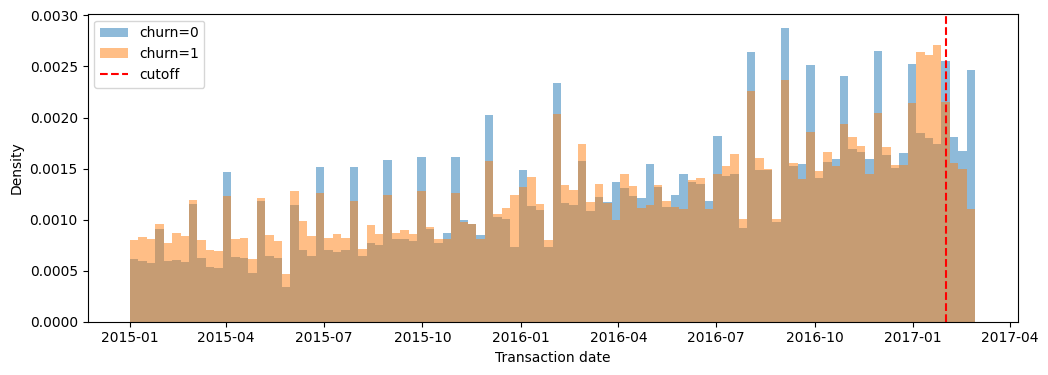

In [23]:
# Ensure dates are datetime
if not pd.api.types.is_datetime64_any_dtype(transactions["transaction_date"]):
    transactions["transaction_date"] = pd.to_datetime(
        transactions["transaction_date"], format="%Y%m%d"
    )

fig, ax = plt.subplots(figsize=(12, 4))
for churn_val in [0, 1]:
    customer_ids = train.loc[train["is_churn"] == churn_val, "msno"]
    subset = transactions.loc[transactions["msno"].isin(customer_ids), "transaction_date"]
    ax.hist(subset, bins=100, alpha=0.5, label=f"churn={churn_val}", density=True)

ax.axvline(CUTOFF_DATE, color="red", linestyle="--", label="cutoff")
ax.set_xlabel("Transaction date")
ax.set_ylabel("Density")
ax.legend()
plt.show()

In [25]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"], format="%Y%m%d"
)
transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"], format="%Y%m%d"
)

transactions_pre = transactions[
    transactions["transaction_date"] < CUTOFF_DATE
].copy()

print(f"total:      {len(transactions):,}")
print(f"pre-cutoff: {len(transactions_pre):,}")
print(f"dropped:    {len(transactions) - len(transactions_pre):,}")

total:      21,547,746
pre-cutoff: 20,639,483
dropped:    908,263


In [26]:
# Should be empty / zero
print(transactions_pre["transaction_date"].max())
# Expected: < 2017-02-01

print((transactions_pre["transaction_date"] >= CUTOFF_DATE).sum())
# Expected: 0

2017-01-31 00:00:00
0


In [29]:
members["registration_init_time"] = pd.to_datetime(
    members["registration_init_time"], format="%Y%m%d" # convert registration date
)

#create a feature
members["tenure_days"] = (CUTOFF_DATE - members["registration_init_time"]).dt.days # for each customer, calculate how many days passed btw reg and cutoff

# bd (age) in KKBox is dirty. Clip and add a missing-indicator.
# TODO: plot members["bd"].describe() to confirm the 10-80 range is sensible.
members["bd_clean"] = members["bd"].where(
    (members["bd"] >= 10) & (members["bd"] <= 80)
)
members["bd_was_invalid"] = members["bd_clean"].isna().astype(int)
members["gender_filled"] = members["gender"].fillna("Unknown")

members_features = members[[
    "msno",
    "city",
    "bd_clean",
    "bd_was_invalid",
    "gender_filled",
    "registered_via",
    "tenure_days",
]].copy()

print(f"bd_clean missing rate: {members_features['bd_clean'].isna().mean():.2%}")
members_features.head()

bd_clean missing rate: 67.22%


,msno,city,bd_clean,bd_was_invalid,gender_filled,registered_via,tenure_days
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,NaN,1,Unknown,11,1970
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,NaN,1,Unknown,7,1967
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,NaN,1,Unknown,11,1966
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,NaN,1,Unknown,11,1966
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32.0,0,female,9,1966


In [28]:
#last transaction
last_txn = transactions_pre.groupby("msno")["transaction_date"].max()

#create a feature - days since last transactions
days_since_last_txn = (CUTOFF_DATE - last_txn).dt.days.rename("days_since_last_txn")

last_expire = (
    transactions_pre.sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
    .set_index("msno")["membership_expire_date"]
)
days_until_expiry_at_cutoff = (last_expire - CUTOFF_DATE).dt.days.rename(
    "days_until_expiry_at_cutoff"
)

txn_agg = transactions_pre.groupby("msno").agg(
    n_transactions=("transaction_date", "count"),
    n_cancels_before_cutoff=("is_cancel", "sum"),
    mean_actual_paid=("actual_amount_paid", "mean"),
    sum_actual_paid=("actual_amount_paid", "sum"),
    mean_list_price=("plan_list_price", "mean"),
    mean_plan_days=("payment_plan_days", "mean"),
    mean_auto_renew=("is_auto_renew", "mean"),
    n_unique_payment_methods=("payment_method_id", "nunique"),
)
txn_agg["discount_ratio"] = np.where(
    txn_agg["mean_list_price"] > 0,
    txn_agg["mean_actual_paid"] / txn_agg["mean_list_price"],
    1.0,
)

latest_payment_method = (
    transactions_pre.sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
    .set_index("msno")["payment_method_id"]
    .rename("latest_payment_method_id")
)

transaction_features = (
    txn_agg
    .join(days_since_last_txn)
    .join(days_until_expiry_at_cutoff)
    .join(latest_payment_method)
    .reset_index()
)

print(f"shape: {transaction_features.shape}")
transaction_features.head()

shape: (2330992, 13)


,msno,n_transactions,n_cancels_before_cutoff,mean_actual_paid,sum_actual_paid,mean_list_price,mean_plan_days,mean_auto_renew,n_unique_payment_methods,discount_ratio,days_since_last_txn,days_until_expiry_at_cutoff,latest_payment_method_id
0,+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=,1,0,0.0,0,0.000000,7.000000,0.0,1,1.000000,145,-140,35
1,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,1,0,1788.0,1788,1788.000000,410.000000,0.0,1,1.000000,438,-28,38
2,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,3,0,99.0,297,99.000000,30.000000,1.0,1,1.000000,17,14,41
3,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,19,0,149.0,2831,141.157895,28.578947,1.0,1,1.055556,1,46,39
4,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,25,0,149.0,3725,143.040000,28.800000,1.0,1,1.041667,6,25,41


In [30]:
df = train.merge(members_features, on="msno", how="left")
df = df.merge(transaction_features, on="msno", how="left")

print(f"shape:      {df.shape}")
print(f"churn rate: {df['is_churn'].mean():.2%}")
print(f"\nmissing rates (top 10):")
print(df.isna().mean().sort_values(ascending=False).head(10))

shape:      (992931, 20)
churn rate: 6.39%

missing rates (top 10):
bd_clean                   0.608425
city                       0.116594
gender_filled              0.116594
bd_was_invalid             0.116594
registered_via             0.116594
tenure_days                0.116594
mean_list_price            0.002112
mean_plan_days             0.002112
n_transactions             0.002112
n_cancels_before_cutoff    0.002112
dtype: float64


In [35]:
y = df["is_churn"]
X = df.drop(columns=["is_churn", "msno"])

In [38]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"numeric:     {len(numeric_features)} cols")
print(f"categorical: {len(categorical_features)} cols")

numeric:     17 cols
categorical: 1 cols


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nX_train: {X_train.shape}  churn: {y_train.mean():.2%}")
print(f"X_test:  {X_test.shape}  churn: {y_test.mean():.2%}")


X_train: (794344, 18)  churn: 6.39%
X_test:  (198587, 18)  churn: 6.39%


In [39]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [41]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['city', 'bd_clean',
                                                   'bd_was_invalid',
                                                   'registered_via',
                                                   'tenure_days',
                                                   'n_transactions',
                                                   'n_cancels_before_cutoff',
                                                   'mean_actual_paid',
                                                   'sum_actual_paid',
                                                   'mean_list_price',
                                                   'mean_plan_days',
                                                   'mean_...',
                                                   'n_unique_payment_methods',
                                                   'discount_ratio',
                                                   'days_since_last_txn',
                                                   'days_until_expiry_at_cutoff',
                                                   'latest_payment_method_id']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender_filled'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [43]:
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_baseline))
print("\nConfusion Matrix:")
print(cm_baseline)

              precision    recall  f1-score   support

           0       0.98      0.86      0.91    185893
           1       0.25      0.69      0.37     12694

    accuracy                           0.85    198587
   macro avg       0.61      0.77      0.64    198587
weighted avg       0.93      0.85      0.88    198587

ROC-AUC: 0.8184230635900738

Confusion Matrix:
[[159781  26112]
 [  3941   8753]]


In [44]:
rf_model_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_model_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['city', 'bd_clean',
                                                   'bd_was_invalid',
                                                   'registered_via',
                                                   'tenure_days',
                                                   'n_transactions',
                                                   'n_cancels_before_cutoff',
                                                   'mean_actual_paid',
                                                   'sum_actual_paid',
                                                   'mean_list_price',
                                                   'mean_plan_days',
                                                   'mean_...
                                                   'n_unique_payment_methods',
                                                   'discount_ratio',
                                                   'days_since_last_txn',
                                                   'days_until_expiry_at_cutoff',
                                                   'latest_payment_method_id']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender_filled'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [48]:
y_pred_rf_balanced = rf_model_balanced.predict(X_test)
y_proba_rf_balanced = rf_model_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_balanced))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96    185893
           1       0.36      0.30      0.33     12694

    accuracy                           0.92    198587
   macro avg       0.66      0.63      0.64    198587
weighted avg       0.91      0.92      0.92    198587

ROC-AUC: 0.8185355109797332

Confusion Matrix:
[[179044   6849]
 [  8851   3843]]


In [46]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['city', 'bd_clean',
                                                   'bd_was_invalid',
                                                   'registered_via',
                                                   'tenure_days',
                                                   'n_transactions',
                                                   'n_cancels_before_cutoff',
                                                   'mean_actual_paid',
                                                   'sum_actual_paid',
                                                   'mean_list_price',
                                                   'mean_plan_days',
                                                   'mean_auto_renew',
                                                   'n_unique_payment_methods',
                                                   'discount_ratio',
                                                   'days_since_last_txn',
                                                   'days_until_expiry_at_cutoff',
                                                   'latest_payment_method_id']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender_filled'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [49]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97    185893
           1       0.60      0.30      0.40     12694

    accuracy                           0.94    198587
   macro avg       0.78      0.64      0.68    198587
weighted avg       0.93      0.94      0.93    198587

ROC-AUC: 0.8637893617130359

Confusion Matrix:
[[183407   2486]
 [  8948   3746]]


### Threshold Tuning

In [51]:
def compute_metrics(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


def best_threshold_for_f1(y_true, y_proba, n_thresholds=200):
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx], thresholds, f1s


def plot_threshold_sweep(name, y_true, y_proba, ax):
    thresholds = np.linspace(0.01, 0.99, 99)

    precisions = []
    recalls = []
    f1s = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred))

    best_t = thresholds[int(np.argmax(f1s))]

    ax.plot(thresholds, precisions, label="Precision")
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, f1s, label="F1", linewidth=2)
    ax.axvline(best_t, linestyle="--", color="gray", alpha=0.6,
               label=f"Best F1 @ {best_t:.2f}")

    ax.set_title(name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

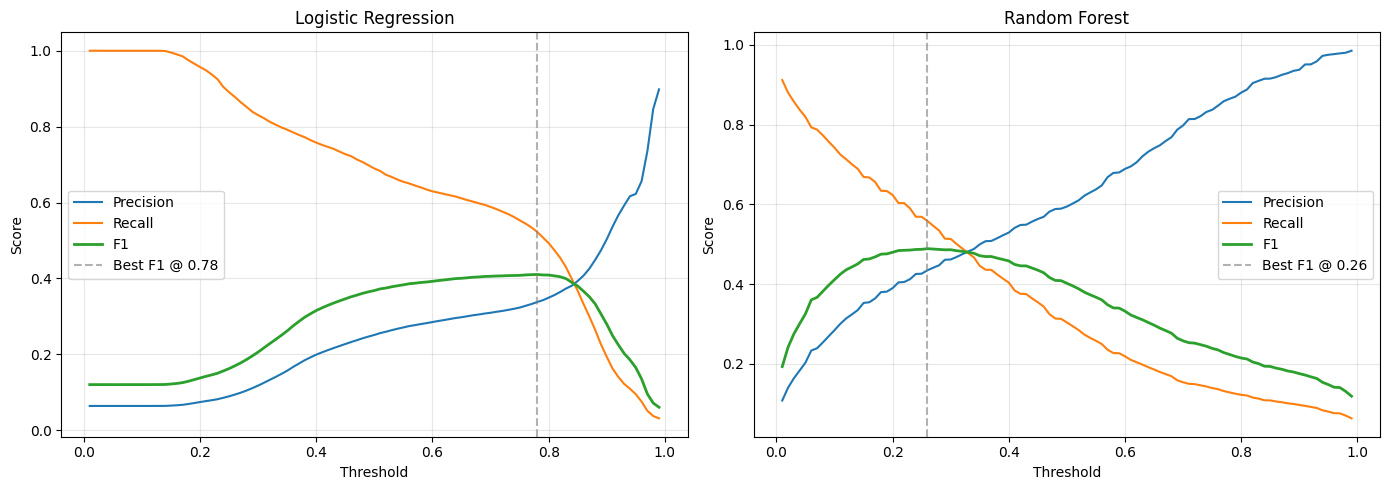

In [52]:
model_probas = {
    "Logistic Regression": y_proba_baseline,
    "Random Forest": y_proba_rf,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_proba) in zip(axes, model_probas.items()):
    plot_threshold_sweep(name, y_test, y_proba, ax)

plt.tight_layout()
plt.show()

In [53]:
tuned_results = []

for name, y_proba in model_probas.items():
    best_t, best_f1, _, _ = best_threshold_for_f1(y_test, y_proba)

    print(f"{name}: best F1 = {best_f1:.4f} at threshold = {best_t:.3f}")

    tuned_results.append(
        compute_metrics(name, y_test, y_proba, threshold=best_t)
    )

tuned_df = pd.DataFrame(tuned_results)
print(tuned_df.to_string(index=False))

Logistic Regression: best F1 = 0.4104 at threshold = 0.778
Random Forest: best F1 = 0.4887 at threshold = 0.256
              model  threshold  accuracy  precision   recall       f1  roc_auc   pr_auc
Logistic Regression   0.778241  0.903584   0.336905 0.525051 0.410444 0.818423 0.351959
      Random Forest   0.256231  0.925317   0.434508 0.558453 0.488745 0.863789 0.480514


### ROC and PR Curves

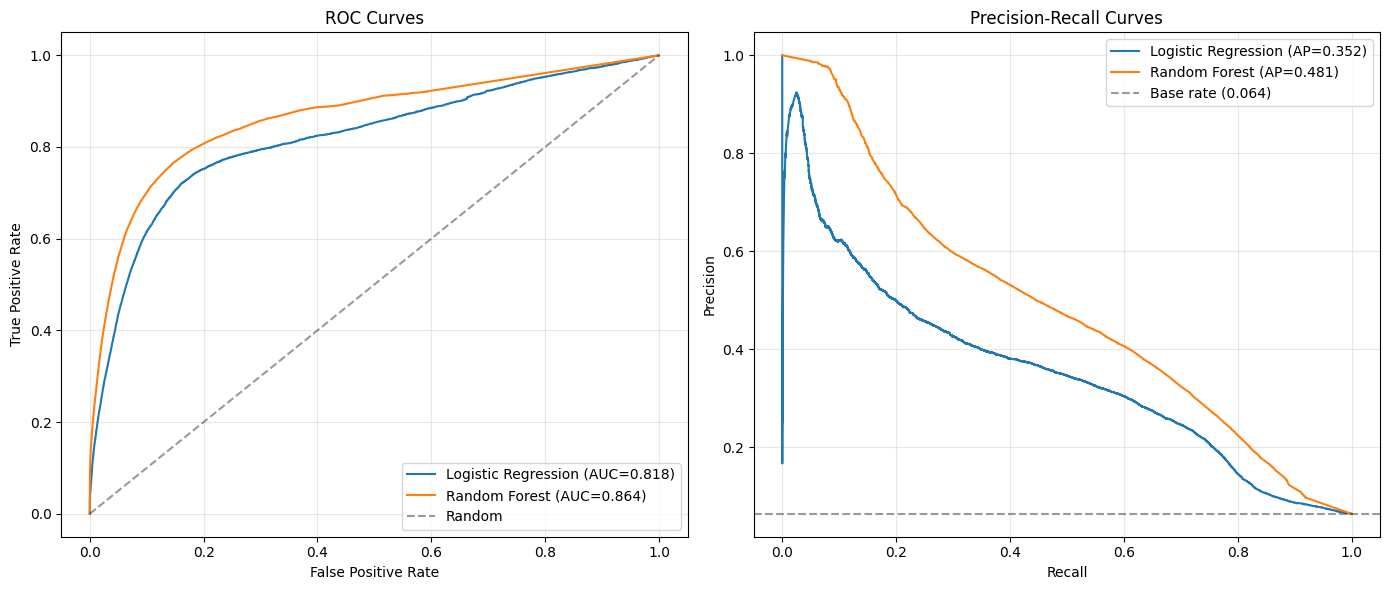

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
for name, y_proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-recall curve
for name, y_proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")

axes[1].axhline(
    y_test.mean(),
    color="k",
    linestyle="--",
    alpha=0.4,
    label=f"Base rate ({y_test.mean():.3f})"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Cross-Validation Sanity Check

In [56]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print(f"Random Forest ROC-AUC across 5 folds: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

Random Forest ROC-AUC across 5 folds: [0.85885021 0.8607188  0.86193765 0.85630863 0.85767132]
Mean: 0.8591  Std: 0.0020


### Final Comparison

In [57]:
lr_metrics = compute_metrics(
    "Logistic Regression",
    y_test,
    y_proba_baseline,
    threshold=0.5
)

rf_metrics = compute_metrics(
    "Random Forest",
    y_test,
    y_proba_rf,
    threshold=0.5
)

all_results = pd.DataFrame([
    lr_metrics,
    rf_metrics,
] + tuned_results)

all_results["tuned"] = all_results["threshold"] != 0.5

print(all_results.to_string(index=False))

              model  threshold  accuracy  precision   recall       f1  roc_auc   pr_auc  tuned
Logistic Regression   0.500000  0.848666   0.251054 0.689538 0.368090 0.818423 0.351959  False
      Random Forest   0.500000  0.942237   0.594324 0.303529 0.401836 0.863789 0.480514  False
Logistic Regression   0.778241  0.903584   0.336905 0.525051 0.410444 0.818423 0.351959   True
      Random Forest   0.256231  0.925317   0.434508 0.558453 0.488745 0.863789 0.480514   True


### Feature Importance for Random Forest

In [58]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

rf_classifier = rf_model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_,
}).sort_values("importance", ascending=False)

print(importance_df.head(20).to_string(index=False))

                         feature  importance
                num__tenure_days    0.172550
num__days_until_expiry_at_cutoff    0.150957
        num__days_since_last_txn    0.125331
            num__mean_auto_renew    0.085162
                   num__bd_clean    0.065614
                       num__city    0.054585
            num__sum_actual_paid    0.054326
           num__mean_actual_paid    0.046466
            num__mean_list_price    0.045295
             num__n_transactions    0.039280
             num__mean_plan_days    0.035375
   num__latest_payment_method_id    0.035350
             num__registered_via    0.022123
             num__discount_ratio    0.016496
   num__n_unique_payment_methods    0.010717
    num__n_cancels_before_cutoff    0.009699
         cat__gender_filled_male    0.009452
       cat__gender_filled_female    0.009375
             num__bd_was_invalid    0.005952
      cat__gender_filled_Unknown    0.005894


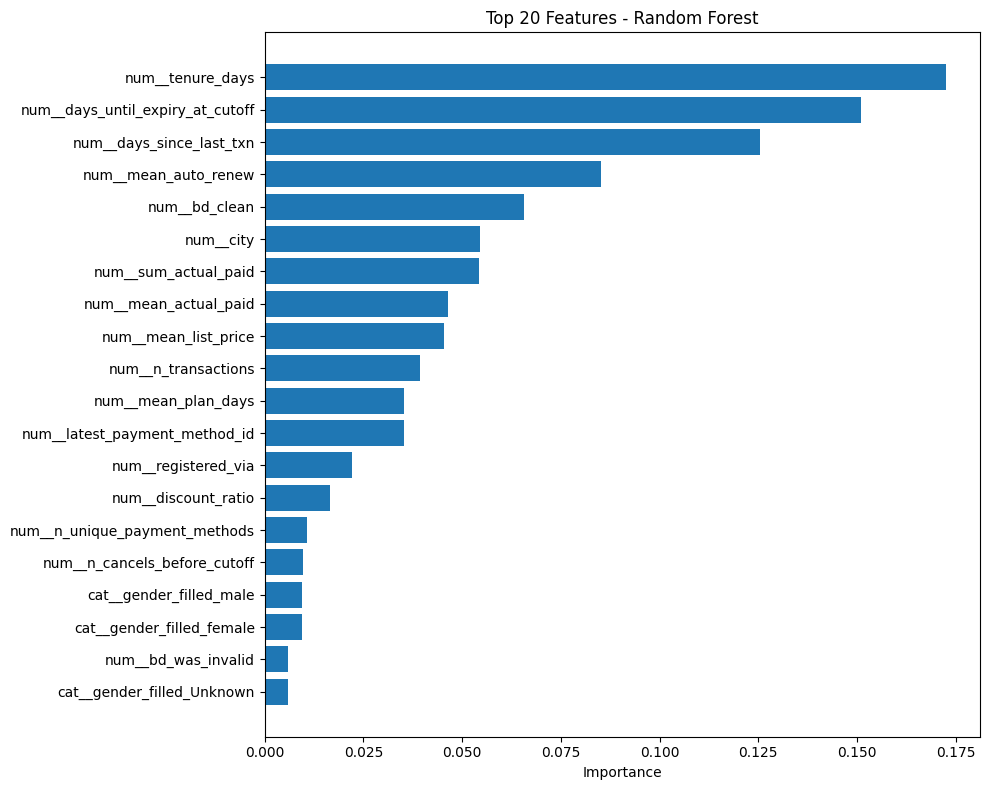

In [59]:
top_20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_20["feature"][::-1], top_20["importance"][::-1])
ax.set_xlabel("Importance")
ax.set_title("Top 20 Features - Random Forest")
plt.tight_layout()
plt.show()

### Save Best Model

In [60]:
candidates = {
    "logistic_regression": (baseline_model, lr_metrics["pr_auc"]),
    "random_forest": (rf_model, rf_metrics["pr_auc"]),
}

best_name = max(candidates, key=lambda k: candidates[k][1])
best_model, best_pr_auc = candidates[best_name]

best_path = MODELS_DIR + f"kkbox_churn_{best_name}.pkl"

joblib.dump(best_model, best_path)

print(f"Best model: {best_name} (PR-AUC = {best_pr_auc:.4f})")
print(f"Saved to:   {best_path}")

Best model: random_forest (PR-AUC = 0.4805)
Saved to:   /kaggle/working/kkbox_churn_random_forest.pkl
